In [1]:
import sys
from pathlib import Path

root = Path.cwd().parent.parent
sys.path.insert(0, str(root))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from pathlib import Path
from datetime import datetime
import json

from sklearn.metrics import classification_report, confusion_matrix
from collections import Counter

from model_shared.rnn_definition import PitchRNN
from model_shared.feature_engineering.pitch_constants import PAD_ID
from pitch_rnn.sequence_builder import PitchSeqDS
from pitch_rnn.export_artifacts import *

In [3]:
def load_model_and_vocabs(vocab_path: str, model_path: str, emb_dims, num_layers):
    cat_vocabs, y_vocab, feature_spec = load_vocabs(vocab_path)
    NUM_COLS = feature_spec["num_cols"]

    cat_vocab_sizes = {c: len(cat_vocabs[c]) + 1 for c in feature_spec["cat_cols"]}
    num_classes = len(y_vocab) + 1

    model = PitchRNN(
        cat_vocab_sizes=cat_vocab_sizes,
        num_features=len(NUM_COLS),
        emb_dims=emb_dims,
        num_classes=num_classes,
        num_layers=num_layers
    )

    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval()

    id_to_pitch = {v: k for k, v in y_vocab.items()}

    return model, cat_vocabs, y_vocab, id_to_pitch, feature_spec, num_classes


In [4]:
def load_test_loader(tensors_path: str, batch_size: int = 64) -> DataLoader:
    tensors = torch.load(tensors_path, map_location="cpu")
    dataset = PitchSeqDS(tensors["Xc"], tensors["Xn"], tensors["Y"])
    return DataLoader(dataset, batch_size=batch_size, shuffle=False)



In [5]:
def load_arsenals(arsenals_path: str = None) -> dict:
    if arsenals_path is None:
        arsenals_path = root / "pitch_arsenal" / "arsenals_all.json"
    with open(arsenals_path) as f:
        arsenals = json.load(f)
    print("Got Arsenals")
    return arsenals

In [6]:
def build_arsenal_masks(arsenals, cat_vocabs, y_vocab, num_classes, year):
    pitcher_vocab = cat_vocabs["pitcher"]
        
    masks = torch.ones(len(pitcher_vocab) + 1, num_classes)

    for pitcher_str, data in arsenals.items():
        pitcher_id_int = int(pitcher_str)

        if pitcher_id_int not in pitcher_vocab:
            continue

        enc_id = pitcher_vocab[pitcher_id_int]

        if year in data:
            allowed_pitches = data[year]["arsenal_mask"]
        elif str(int(year) - 1) in data:
            allowed_pitches = data[str(int(year) - 1)]["arsenal_mask"]
        else:
            continue

        masks[enc_id] = 0
        for pitch in allowed_pitches:
            if pitch in y_vocab:
                masks[enc_id, y_vocab[pitch]] = 1

    return masks

In [7]:
def get_all_predictions(model, test_loader, device, arsenal_masks=None, pad_id=PAD_ID):
    model.eval()
    all_preds, all_true = [], []

    with torch.no_grad():
        for x_cat, x_num, y in test_loader:
            x_cat = x_cat.to(device)
            x_num = x_num.to(device)
            y     = y.to(device)

            logits = model(x_cat, x_num)

            if arsenal_masks is not None:
                pitcher_ids   = x_cat[:, :, 0]
                pitch_mask    = arsenal_masks[pitcher_ids].to(device)
                logits        = logits.masked_fill(pitch_mask == 0, float("-inf"))

            preds = logits.argmax(dim=-1)
            valid = (y != pad_id).bool()

            all_preds.append(preds[valid].cpu().numpy())
            all_true.append(y[valid].cpu().numpy())

    return np.concatenate(all_true), np.concatenate(all_preds)

In [8]:
def get_accuracy(model, test_loader, device, arsenal_masks=None, pad_id=PAD_ID):
    y_true, y_pred = get_all_predictions(model, test_loader, device, arsenal_masks, pad_id)
    accuracy = 100 * (y_pred == y_true).sum() / len(y_true)
    print(f"Token Accuracy (no PAD): {accuracy:.2f}%")
    return accuracy


In [9]:
def get_top_k_accuracy(model, test_loader, device, arsenal_masks=None, K=3, pad_id=PAD_ID):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x_cat, x_num, y in test_loader:
            x_cat = x_cat.to(device)
            x_num = x_num.to(device)
            y     = y.to(device)

            logits = model(x_cat, x_num)

            if arsenal_masks is not None:
                pitcher_ids = x_cat[:, :, 0]
                pitch_mask  = arsenal_masks[pitcher_ids].to(device)
                logits      = logits.masked_fill(pitch_mask == 0, float("-inf"))

            topk  = logits.topk(K, dim=-1).indices
            valid = (y != pad_id)
            match = (topk == y.unsqueeze(-1)).any(dim=-1)
            correct += (match & valid).sum().item()
            total   += valid.sum().item()

    accuracy = 100 * correct / total
    print(f"Top-{K} Accuracy: {accuracy:.2f}%")
    return accuracy

In [10]:
def get_most_common_pitches(model, test_loader, device, id_to_pitch, arsenal_masks=None, top_n=5, pad_id=PAD_ID):
    model.eval()
    counts = Counter()

    with torch.no_grad():
        for x_cat, x_num, y in test_loader:
            x_cat = x_cat.to(device)
            x_num = x_num.to(device)

            logits = model(x_cat, x_num)

            if arsenal_masks is not None:
                pitcher_ids = x_cat[:, :, 0]
                pitch_mask  = arsenal_masks[pitcher_ids].to(device)
                logits      = logits.masked_fill(pitch_mask == 0, float("-inf"))

            preds = logits.argmax(dim=-1)
            for p in preds.view(-1).tolist():
                if p != pad_id:
                    counts[p] += 1

    print(f"Top {top_n} most predicted pitches:")
    for pid, cnt in counts.most_common(top_n):
        print(f"  {id_to_pitch.get(pid, 'PAD')}: {cnt}")

    return counts.most_common(top_n)

In [11]:
def print_classification_report(model, test_loader, device, id_to_pitch, arsenal_masks=None, pad_id=PAD_ID):
    y_true, y_pred = get_all_predictions(model, test_loader, device, arsenal_masks, pad_id)
    labels       = sorted(id_to_pitch.keys())
    target_names = [id_to_pitch[l] for l in labels]
    report = classification_report(y_true, y_pred, labels=labels, target_names=target_names)
    print(report)
    return report

In [12]:
def generate_confusion_matrix(
    model, test_loader, device, id_to_pitch,
    arsenal_masks=None, pad_id=PAD_ID,
    figsize=(12, 10), save_dir: str = None
):
    y_true, y_pred = get_all_predictions(model, test_loader, device, arsenal_masks, pad_id)

    labels      = sorted(id_to_pitch.keys())
    tick_labels = [id_to_pitch[l] for l in labels]

    cm      = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        cm_norm,
        xticklabels=tick_labels,
        yticklabels=tick_labels,
        cmap="Blues",
        annot=True,
        fmt=".2f",
        ax=ax,
    )
    ax.set_xlabel("Predicted Pitch Type")
    ax.set_ylabel("True Pitch Type")
    ax.set_title("Pitch Type Confusion Matrix (Token-Level)")
    plt.tight_layout()

    if save_dir is not None:
        out_path = Path(save_dir)
        out_path.mkdir(parents=True, exist_ok=True)
        filename  = f"confusion_matrix_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png"
        save_path = out_path / filename
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Confusion matrix saved {save_path}")

    plt.show()
    return cm, cm_norm

In [13]:
def evaluate_model_complete(
    model, test_loader, device, id_to_pitch,
    arsenal_masks=None, pad_id=PAD_ID,
    confusion_matrix_save_dir: str = None,
):

    print("\n1. Token Accuracy:")
    acc = get_accuracy(model, test_loader, device, arsenal_masks, pad_id)

    print("\n2. Top-3 Accuracy:")
    top3 = get_top_k_accuracy(model, test_loader, device, arsenal_masks, K=3, pad_id=pad_id)

    print("\n3. Most Common Predictions:")
    common = get_most_common_pitches(model, test_loader, device, id_to_pitch, arsenal_masks, pad_id=pad_id)

    print("\n4. Detailed Classification Report:")
    class_report = print_classification_report(model, test_loader, device, id_to_pitch, arsenal_masks, pad_id)

    print("\n5. Confusion Matrix:")
    cm, cm_norm = generate_confusion_matrix(
        model, test_loader, device, id_to_pitch,
        arsenal_masks=arsenal_masks,
        pad_id=pad_id,
        save_dir=confusion_matrix_save_dir,
    )

    return {
        "accuracy":                   acc,
        "top3_accuracy":              top3,
        "most_common":                common,
        "classification_report":      class_report,
        "confusion_matrix":           cm,
        "confusion_matrix_normalized": cm_norm,
    }

In [17]:
def evaluate_rnn(emb_dims, num_layers):
    print("HLpp")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    vocab_path = get_latest_file(root / "model_shared" / "vocab", "rnn_vocab_*.json")
    model_path = get_latest_file(root / "model_shared" / "trained-parameters", "pitch_rnn_*.pt")
    tensors_path = get_latest_file(root / "model_shared" / "test-data", "test_tensors_*.pt")

    model, cat_vocabs, y_vocab, id_to_pitch, feature_spec, num_classes = load_model_and_vocabs(
        vocab_path = vocab_path,
        model_path = model_path,
        emb_dims=emb_dims,
        num_layers=num_layers
    )

    print
    
    print("y_vocab sample:", list(y_vocab.items())[:5])
    print("id_to_pitch sample:", list(id_to_pitch.items())[:5])

    test_loader  = load_test_loader(tensors_path)
    arsenals     = load_arsenals()
    arsenal_masks = build_arsenal_masks(arsenals, cat_vocabs, y_vocab, num_classes, year="2025")

    evaluate_model_complete(
        model, test_loader, device, id_to_pitch,
        arsenal_masks=None,
        confusion_matrix_save_dir=None,
    )

HLpp
y_vocab sample: [('breaking', 1), ('fastball', 2), ('offspeed', 3)]
id_to_pitch sample: [(1, 'breaking'), (2, 'fastball'), (3, 'offspeed')]
Got Arsenals

1. Token Accuracy:
Token Accuracy (no PAD): 55.93%

2. Top-3 Accuracy:
Top-3 Accuracy: 100.00%

3. Most Common Predictions:
Top 5 most predicted pitches:
  fastball: 167629
  breaking: 53113
  offspeed: 36402

4. Detailed Classification Report:
              precision    recall  f1-score   support

    breaking       0.52      0.43      0.47     32793
    fastball       0.63      0.66      0.65     55884
    offspeed       0.40      0.46      0.43     16238

    accuracy                           0.56    104915
   macro avg       0.52      0.52      0.51    104915
weighted avg       0.56      0.56      0.56    104915


5. Confusion Matrix:


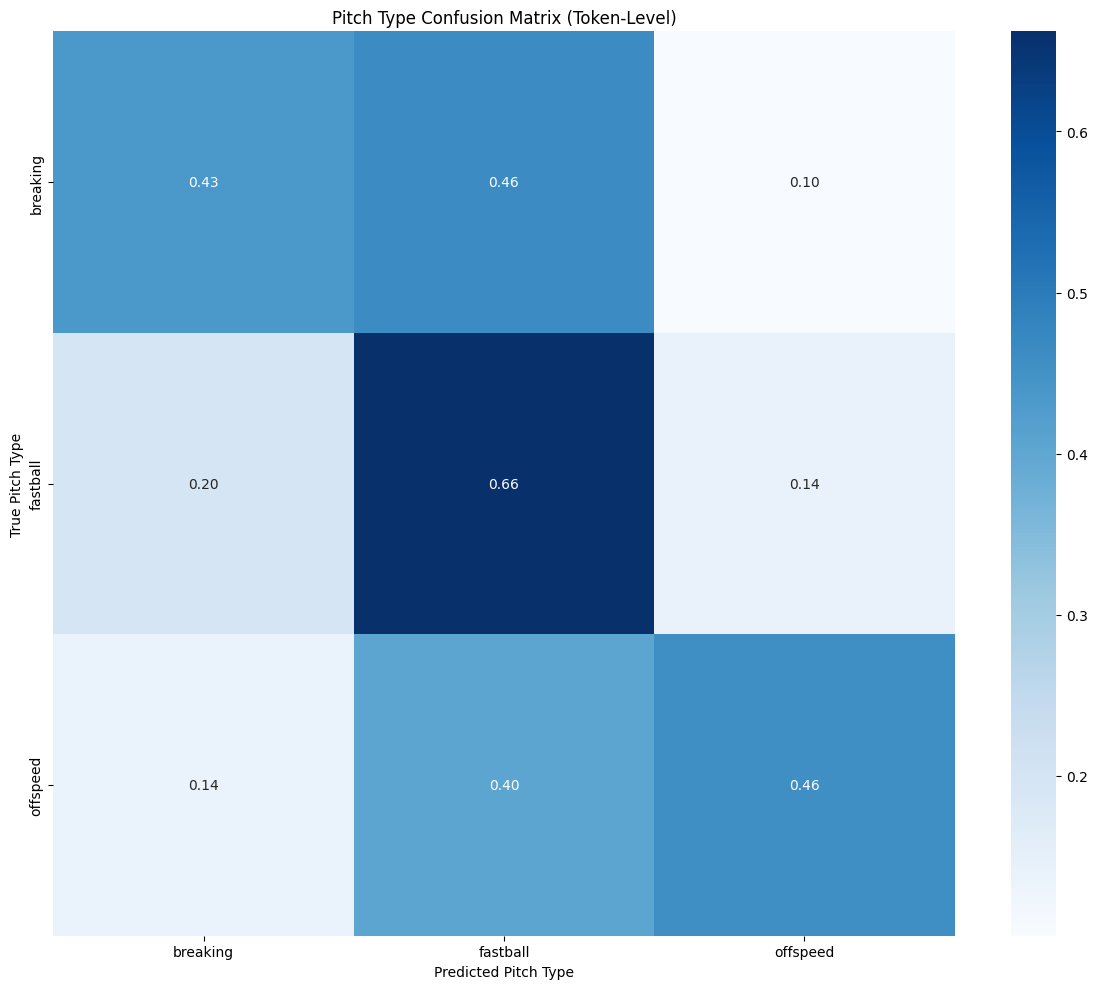

In [18]:
EMB_DIMS = {
    "pitcher": 32,
    "batter":  32,
    "stand": 4,
    "p_throws": 4,
    "inning_topbot": 4,
    "count_state": 8,
    "prev_pitch_type": 16,
    "count_situation": 4,
}

evaluate_rnn(emb_dims=EMB_DIMS, num_layers=2)